# Chapter 6. ML and DL for ECG

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

In [ ]:
# load the Excel file as a DataFrame
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/ECG_Dataset/ECG.csv")
display(eeg_data.head())

,RECORD,hbpermin,Pseg,PQseg,QRSseg,QRseg,QTseg,RSseg,STseg,Tseg,...,IBISD,SDSD,RMSSD,QRSarea,QRSperi,PQslope,STslope,NN50,pNN50,ECG_signal
0,1,74.925669,0.076508,0.108889,0.088254,0.043571,0.193016,0.044683,0.104762,0.130476,...,17.389965,27.158481,292.296636,18.457618,63.615239,-0.014364,0.012606,2,5.882353,ARR
1,2,68.503469,0.072483,0.096181,0.093924,0.046267,0.193490,0.047656,0.099566,0.089149,...,10.787886,9.665517,318.563915,23.043230,67.787773,-0.021207,0.016175,1,3.225806,ARR
2,3,83.488603,0.071154,0.086610,0.039530,0.018590,0.132479,0.020940,0.092949,0.094444,...,85.647434,111.816694,273.165412,10.756353,29.253827,-0.042542,0.027131,16,42.105263,ARR
3,4,68.503469,0.082812,0.108160,0.090365,0.045226,0.188802,0.045139,0.098437,0.088281,...,11.604875,11.193252,313.046941,23.845086,65.228737,-0.017806,0.017022,2,6.451613,ARR
4,5,82.080000,0.070760,0.102632,0.101023,0.049415,0.193713,0.051608,0.092690,0.085965,...,36.264564,60.245998,263.225677,20.942791,72.830353,-0.016650,0.016191,2,5.405405,ARR


**Make Labeling**

In [ ]:

# Define a mapping from textual labels to numeric labels
label_mapping = {
    "ARR": 0,
    "AFF": 1,
    "CHF": 2,
    "NSR": 3
}

# Create a new numeric column for the labels
eeg_data['ECG_label'] = eeg_data['ECG_signal'].map(label_mapping)

# Optional: drop the original text labels if you don't need them
# eeg_data = eeg_data.drop(columns=['ECG_signal'])

display(eeg_data.head())

,RECORD,hbpermin,Pseg,PQseg,QRSseg,QRseg,QTseg,RSseg,STseg,Tseg,...,SDSD,RMSSD,QRSarea,QRSperi,PQslope,STslope,NN50,pNN50,ECG_signal,ECG_label
0,1,74.925669,0.076508,0.108889,0.088254,0.043571,0.193016,0.044683,0.104762,0.130476,...,27.158481,292.296636,18.457618,63.615239,-0.014364,0.012606,2,5.882353,ARR,0
1,2,68.503469,0.072483,0.096181,0.093924,0.046267,0.193490,0.047656,0.099566,0.089149,...,9.665517,318.563915,23.043230,67.787773,-0.021207,0.016175,1,3.225806,ARR,0
2,3,83.488603,0.071154,0.086610,0.039530,0.018590,0.132479,0.020940,0.092949,0.094444,...,111.816694,273.165412,10.756353,29.253827,-0.042542,0.027131,16,42.105263,ARR,0
3,4,68.503469,0.082812,0.108160,0.090365,0.045226,0.188802,0.045139,0.098437,0.088281,...,11.193252,313.046941,23.845086,65.228737,-0.017806,0.017022,2,6.451613,ARR,0
4,5,82.080000,0.070760,0.102632,0.101023,0.049415,0.193713,0.051608,0.092690,0.085965,...,60.245998,263.225677,20.942791,72.830353,-0.016650,0.016191,2,5.405405,ARR,0


Scaling data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Assuming 'ECG_label' is your target, and all other columns are features
features = eeg_data.drop(columns=['ECG_signal', 'ECG_label'])  # remove labels and original text
labels = eeg_data['ECG_label']  # numeric labels

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform the feature data
features_scaled = scaler.fit_transform(features)

# Convert back to DataFrame with original column names
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

# Add back the labels
features_scaled_df['ECG_label'] = labels.values

# Optional: add back original ECG_signal column if needed
#features_scaled_df['ECG_signal'] = eeg_data['ECG_signal'].values

# Display the final DataFrame
display(features_scaled_df.head())


,RECORD,hbpermin,Pseg,PQseg,QRSseg,QRseg,QTseg,RSseg,STseg,Tseg,...,IBISD,SDSD,RMSSD,QRSarea,QRSperi,PQslope,STslope,NN50,pNN50,ECG_label
0,0.000000,0.420396,0.744997,0.636931,0.734471,0.667477,0.838939,0.765986,0.608827,0.584427,...,0.016162,0.015279,0.162753,0.557110,0.734782,0.958341,0.028271,0.054054,0.111562,0
1,0.000834,0.376898,0.690425,0.511170,0.781655,0.708777,0.843156,0.816964,0.548483,0.331626,...,0.009737,0.005139,0.181294,0.695519,0.782976,0.926436,0.051082,0.027027,0.061179,0
2,0.001668,0.478394,0.672411,0.416457,0.328978,0.284779,0.300114,0.358974,0.471634,0.364017,...,0.082597,0.064352,0.149250,0.324661,0.337893,0.826980,0.121113,0.432432,0.798548,0
3,0.002502,0.376898,0.830469,0.629715,0.752036,0.692819,0.801433,0.773810,0.535378,0.326316,...,0.010532,0.006024,0.177400,0.719721,0.753418,0.942293,0.056493,0.054054,0.122358,0
4,0.003336,0.468853,0.667074,0.575009,0.840741,0.756999,0.845148,0.884712,0.468630,0.312147,...,0.034533,0.034459,0.142234,0.632121,0.841220,0.947681,0.051184,0.054054,0.102516,0


**Mix Data**

In [ ]:
# Shuffle the dataset randomly
features_scaled_mix = features_scaled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the result
display(features_scaled_mix.head())


,RECORD,hbpermin,Pseg,PQseg,QRSseg,QRseg,QTseg,RSseg,STseg,Tseg,...,IBISD,SDSD,RMSSD,QRSarea,QRSperi,PQslope,STslope,NN50,pNN50,ECG_label
0,0.982485,0.402190,0.571235,0.527188,0.623217,0.580160,0.647378,0.634527,0.514134,0.324218,...,0.011428,0.001865,0.031740,0.262210,0.272294,0.780094,0.259381,0.135135,0.058176,3
1,0.721435,0.593614,0.539918,0.120613,0.072919,0.068571,0.067825,0.073469,0.525873,0.804642,...,0.003763,0.001671,0.060909,0.000000,0.000000,0.534509,0.154049,0.000000,0.000000,2
2,0.084237,0.673672,0.804216,0.770463,0.749535,0.704583,0.821225,0.755495,0.564691,0.576743,...,0.024846,0.023799,0.091681,0.274978,0.749882,1.000000,0.000000,0.135135,0.185936,0
3,0.366138,0.735849,0.540962,0.505314,0.566846,0.525719,0.594652,0.579332,0.524002,0.440306,...,0.043473,0.043587,0.050808,0.401226,0.507693,0.908601,0.107872,0.567568,0.375732,1
4,0.048374,0.507393,0.506868,0.054169,0.000000,0.000000,0.042388,0.000000,0.594439,0.401731,...,0.003459,0.002731,0.126256,0.000000,0.000000,0.692637,0.086715,0.000000,0.000000,0


**Machine Learning**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming features_scaled_df is your preprocessed DataFrame
# Separate features (X) and target (y)
#X = features_scaled_mix.drop(columns=['ECG_label', 'ECG_signal'], errors='ignore')

X = features_scaled_df.drop(columns=['RECORD', 'ECG_label', 'ECG_signal'], errors='ignore')
y = features_scaled_df['ECG_label']
y = features_scaled_mix['ECG_label']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    max_depth=None,    # allow trees to expand fully
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['ARR', 'AFF', 'CHF', 'NSR']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.2917

Classification Report:
              precision    recall  f1-score   support

         ARR       0.34      0.41      0.37        90
         AFF       0.27      0.22      0.24        90
         CHF       0.26      0.22      0.24        90
         NSR       0.28      0.31      0.30        90

    accuracy                           0.29       360
   macro avg       0.29      0.29      0.29       360
weighted avg       0.29      0.29      0.29       360

Confusion Matrix:
[[37 11 17 25]
 [22 20 19 29]
 [31 22 20 17]
 [19 22 21 28]]


**Hyper parameters**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Prepare features and labels ---
# Drop non-feature columns
X = features_scaled_df.drop(columns=['RECORD', 'ECG_label', 'ECG_signal'], errors='ignore')
y = features_scaled_df['ECG_label']

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Initialize Random Forest with tuned hyperparameters ---
rf_model = RandomForestClassifier(
    n_estimators=500,         # more trees for stability
    max_depth=20,             # limit depth to reduce overfitting
    min_samples_split=5,      # min samples to split a node
    min_samples_leaf=2,       # min samples in leaf nodes
    max_features='sqrt',      # number of features considered at each split
    class_weight='balanced',  # balance class weights automatically
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)

# --- Train the model ---
rf_model.fit(X_train, y_train)

# --- Make predictions ---
y_pred = rf_model.predict(X_test)

# --- Evaluate the model ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['ARR', 'AFF', 'CHF', 'NSR']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))




Test Accuracy: 0.9889

Classification Report:
              precision    recall  f1-score   support

         ARR       0.99      1.00      0.99        90
         AFF       0.99      0.98      0.98        90
         CHF       0.98      0.98      0.98        90
         NSR       1.00      1.00      1.00        90

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Confusion Matrix:
[[90  0  0  0]
 [ 0 88  2  0]
 [ 1  1 88  0]
 [ 0  0  0 90]]


**Which hyper parameters were choosed**





In [ ]:
# Print all hyperparameters of the trained Random Forest
params = rf_model.get_params()
for key, value in params.items():
    print(f"{key}: {value}")


bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 20
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 2
min_samples_split: 5
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 500
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [ ]:
print("n_estimators:", rf_model.n_estimators)
print("max_depth:", rf_model.max_depth)
print("min_samples_split:", rf_model.min_samples_split)
print("min_samples_leaf:", rf_model.min_samples_leaf)
print("max_features:", rf_model.max_features)
print("class_weight:", rf_model.class_weight)


n_estimators: 500
max_depth: 20
min_samples_split: 5
min_samples_leaf: 2
max_features: sqrt
class_weight: balanced


**Feature analasy**

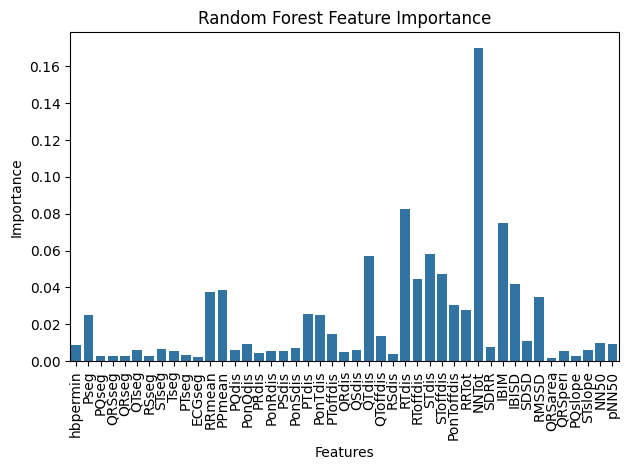

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X.columns

# Vertical bar plot
sns.barplot(x=feature_names, y=importances)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.ylabel("Importance")
plt.xlabel("Features")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


**`Cross Validation`**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("5-Fold CV Accuracy:", scores)
print("Mean CV Accuracy:", scores.mean())


5-Fold CV Accuracy: [0.875      0.98333333 1.         1.         0.89166667]
Mean CV Accuracy: 0.95


**Deep Learning**

In [ ]:
#1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#2. Prepare Features and Labels

# Features (X) → remove non-features
X = features_scaled_df.drop(columns=['RECORD', 'ECG_label', 'ECG_signal'], errors='ignore').values

# Labels (y)
y = features_scaled_df['ECG_label'].values

# One-hot encoding for Deep Learning
y_cat = to_categorical(y, num_classes=4)

#3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

#4. Build Deep Learning Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(4, activation='softmax')  # 4 ECG classes
])
#5. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#6. Train the Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

#7. Evaluate the Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

#8. Classification Report & Confusion Matrix
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['ARR', 'AFF', 'CHF', 'NSR']))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3857 - loss: 1.3483 - val_accuracy: 0.5595 - val_loss: 1.2207
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7615 - loss: 0.6481 - val_accuracy: 0.7440 - val_loss: 1.1246
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8645 - loss: 0.4208 - val_accuracy: 0.7321 - val_loss: 1.0423
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8766 - loss: 0.3724 - val_accuracy: 0.5893 - val_loss: 0.9918
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9257 - loss: 0.2667 - val_accuracy: 0.5952 - val_loss: 0.9216
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9086 - loss: 0.2549 - val_accuracy: 0.5595 - val_loss: 0.8827
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9319 - loss: 0.2335 - val_accuracy: 0.5893 - val_loss: 0.8099
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9239 - loss: 0.2467 - val_accuracy: 0.5952 - val_loss

**Hyper parameters**

In [ ]:
# 1. Import
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 2. Hyperparameters (VERY IMPORTANT)
# Model hyperparameters
N_CLASSES = 4
HIDDEN_UNITS_1 = 128
HIDDEN_UNITS_2 = 64
HIDDEN_UNITS_3 = 32
DROPOUT_RATE = 0.3
ACTIVATION = 'relu'

# Training hyperparameters
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 50
VALIDATION_SPLIT = 0.2

#3.Prepare Features and Labels
# Features (X)
X = features_scaled_df.drop(
    columns=['RECORD', 'ECG_label', 'ECG_signal'],
    errors='ignore'
).values

# Labels (y)
y = features_scaled_df['ECG_label'].values

# One-hot encoding
y_cat = to_categorical(y, num_classes=N_CLASSES)

# 4. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#5. Build Deep Learning Model
model = Sequential([
    Dense(HIDDEN_UNITS_1, activation=ACTIVATION, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),

    Dense(HIDDEN_UNITS_2, activation=ACTIVATION),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),

    Dense(HIDDEN_UNITS_3, activation=ACTIVATION),

    Dense(N_CLASSES, activation='softmax')
])
# 6. Compile the Model
optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7.Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1
)

#8. Evaluate the Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 9. Classification Report & Confusion Matrix.
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['ARR', 'AFF', 'CHF', 'NSR']))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4045 - loss: 1.3890 - val_accuracy: 0.5417 - val_loss: 1.2528
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7986 - loss: 0.5812 - val_accuracy: 0.6369 - val_loss: 1.1532
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8690 - loss: 0.4201 - val_accuracy: 0.5536 - val_loss: 1.0880
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8662 - loss: 0.3429 - val_accuracy: 0.4821 - val_loss: 1.1208
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9040 - loss: 0.2877 - val_accuracy: 0.4524 - val_loss: 1.1619
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9114 - loss: 0.2365 - val_accuracy: 0.4583 - val_loss: 1.1240
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9051 - loss: 0.2383 - val_accuracy: 0.4702 - val_loss: 1.0539
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9149 - loss: 0.1952 - val_accuracy: 0.6250 - v

**Validation**

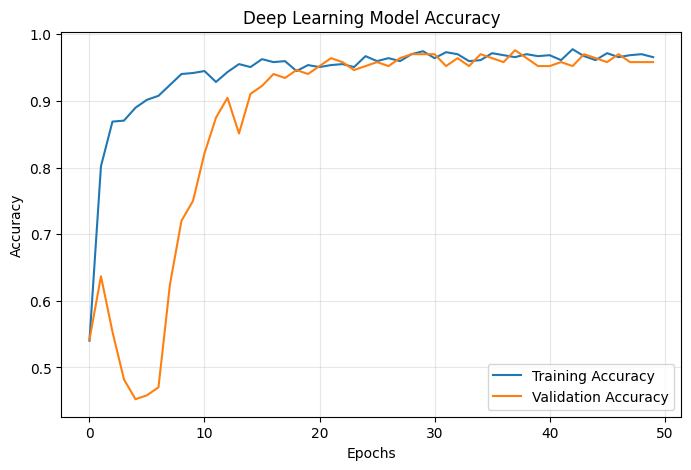

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deep Learning Model Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**The end of the chapter 2**